# Text-as-Image Compression Research: Full End-to-End Pipeline
### Multimodal Vision Language Model Evaluation with `gemma4:31b`

This complete notebook implements the exact methodology from **"Text-as-Image Compression for Multimodal LLMs"**:
1. **Environment & Model Setup**: Connect to `gemma4:31b` via Ollama API with deterministic sampling (`temperature = 0`).
2. **Text Normalization & Rasterization Engine**: Convert text into standardized high-contrast images across discrete visual token budgets (**70, 140, 280, 560, 1120**).
3. **RULER Benchmark Generator**: Generate synthetic needle-in-a-haystack retrieval challenges across **500 to 5,000** context tokens.
4. **Condition A vs Condition B Execution**: Test Raw Text vs Single-Image representations.
5. **Methodology Metrics & Logging**: Track Prompt Tokens ($m+q$), Visual Tokens ($k+q$), Latency, and **Compression Ratio (CR)**.
6. **Visual Analysis & Degradation Curves**: Interactive plots showing the exact point of performance degradation.

In [1]:
# =============================================================================
# Step 1: Dependencies, Imports & Model Verification
# =============================================================================
import time
import io
import random
import re
import unicodedata
import textwrap
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from ollama import chat

MODEL_NAME = 'gemma4:31b'

# Verify Ollama connection
warmup = chat(model=MODEL_NAME, messages=[{'role': 'user', 'content': 'Hello!'}])
print(f"Connected to Vision Language Model: {MODEL_NAME}")
print(f"Test Ping Response: {warmup.message.content.strip()}")

Connected to Vision Language Model: gemma4:31b
Test Ping Response: Hello! How can I help you today?


In [2]:
# =============================================================================
# Step 2: High-Density Text-to-Image Rasterizer with Discrete Token Budgets
# =============================================================================
BUDGET_CONFIGS = {
    70:   {"width": 450,  "font_size": 14, "line_spacing": 4, "wrap_width": 60, "padding": 20},
    140:  {"width": 650,  "font_size": 16, "line_spacing": 5, "wrap_width": 72, "padding": 25},
    280:  {"width": 850,  "font_size": 18, "line_spacing": 6, "wrap_width": 85, "padding": 30},
    560:  {"width": 1100, "font_size": 20, "line_spacing": 7, "wrap_width": 95, "padding": 35},
    1120: {"width": 1400, "font_size": 22, "line_spacing": 8, "wrap_width": 115, "padding": 40},
}

def normalize_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()

def render_text_to_image(
    text: str,
    token_budget: int = 560,
    bg_color: str = "white",
    text_color: str = "black"
) -> Image.Image:
    text = normalize_text(text)
    config = BUDGET_CONFIGS.get(token_budget, BUDGET_CONFIGS[560])

    font_size = config["font_size"]
    image_width = config["width"]
    padding = config["padding"]
    line_spacing = config["line_spacing"]
    wrap_width = config["wrap_width"]

    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()

    formatted_lines = []
    for paragraph in text.split("\n\n"):
        formatted_lines.extend(textwrap.wrap(paragraph, width=wrap_width))
        formatted_lines.append("")

    line_height = font_size + line_spacing
    image_height = 2 * padding + max(len(formatted_lines) * line_height, 80)

    img = Image.new("RGB", (image_width, image_height), color=bg_color)
    draw = ImageDraw.Draw(img)

    y = padding
    for line in formatted_lines:
        if line:
            draw.text((padding, y), line, fill=text_color, font=font)
        y += line_height

    return img

def image_to_bytes(img: Image.Image) -> bytes:
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return buf.getvalue()

print("Rasterizer Engine Ready with Budgets:", list(BUDGET_CONFIGS.keys()))

Rasterizer Engine Ready with Budgets: [70, 140, 280, 560, 1120]


In [3]:
# =============================================================================
# Step 3: RULER Needle-in-a-Haystack Benchmark Generator (500 - 5000 Tokens)
# =============================================================================
DISTRACTORS = [
    "The thermal radiator on the secondary boom radiates excess heat into cold space at roughly 4 kelvins.",
    "Subsystem bus voltage fluctuates within an allowable tolerance of positive or negative 0.15 volts direct current.",
    "Star tracking sensor arrays refresh coordinate quaternions at an operational cadence of thirty hertz.",
    "Liquid nitrogen boil-off lines are purged automatically during solar occultation intervals.",
    "Reaction wheels one and three reached peak angular momentum before momentum dumping thrusters fired.",
    "Micrometeoroid shielding panels withstood seventy-four microscopic impact events during the outer flyby.",
    "Optical payload mirrors are coated with ultra-thin protected gold films optimized for near-infrared reflection.",
    "The radioisotope thermoelectric generator generates approximately one hundred and fifty-seven watts of thermal output.",
    "Telemetry packets transmitted across the S-band downlink utilize Reed-Solomon forward error correction codes.",
    "Autonomous attitude determination algorithms rely on gyroscopic ring laser drift sensors during occultation."
]

def generate_ruler_task(target_tokens=500, needle_depth=0.5, seed=42):
    rng = random.Random(seed)
    secret_code = f"CIPHER-{rng.randint(1000, 9999)}-{rng.choice(['OMEGA', 'KAPPA', 'DELTA', 'SIGMA'])}"
    needle = f"Special authorization key {secret_code} was recorded in emergency protocol ledger section 9."
    question = "What special authorization key was recorded in emergency protocol ledger section 9?"
    
    target_words = int(target_tokens * 0.75)
    paragraphs = []
    cur_words = 0
    
    while cur_words < target_words:
        sentences = [rng.choice(DISTRACTORS) for _ in range(rng.randint(4, 6))]
        para = " ".join(sentences)
        paragraphs.append(para)
        cur_words += len(para.split())
        
    # Insert needle
    ins_idx = max(0, min(int(len(paragraphs) * needle_depth), len(paragraphs) - 1))
    words = paragraphs[ins_idx].split()
    words.insert(len(words) // 2, needle)
    paragraphs[ins_idx] = " ".join(words)
    
    context = "\n\n".join(paragraphs)
    return {
        "target_tokens": target_tokens,
        "context": context,
        "question": question,
        "ground_truth": secret_code,
        "needle": needle
    }

# Preview a sample test task
sample_task = generate_ruler_task(target_tokens=500, seed=123)
print(f"Generated RULER Task: ~{sample_task['target_tokens']} tokens")
print(f"Target Ground Truth Needle: {sample_task['ground_truth']}")

Generated RULER Task: ~500 tokens
Target Ground Truth Needle: CIPHER-1857-DELTA


In [4]:
# =============================================================================
# Step 4: Run Condition A (Text) vs Condition B (Image) across Context Lengths
# =============================================================================
# Select target context lengths (e.g. 500, 1000, 1500 tokens)
TEST_LENGTHS = [500, 1000, 1500]
TARGET_BUDGET = 560

benchmark_records = []

for length in TEST_LENGTHS:
    print("-" * 70)
    print(f"Testing Context Length: ~{length} Tokens")
    task = generate_ruler_task(target_tokens=length, seed=length)
    ctx = task["context"]
    q = task["question"]
    gt = task["ground_truth"]
    
    # --- Condition A: Raw Text Baseline ---
    t0 = time.time()
    res_text = chat(
        model=MODEL_NAME,
        messages=[{'role': 'user', 'content': f"Context Document:\n{ctx}\n\nQuestion: {q}"}],
        options={'temperature': 0.0}
    )
    latency_text = time.time() - t0
    prompt_tokens_text = res_text.prompt_eval_count
    ans_text = res_text.message.content.strip()
    acc_text = 1.0 if gt.lower() in ans_text.lower() else 0.0
    
    # --- Condition B: Text-as-Image Experimental ---
    img = render_text_to_image(ctx, token_budget=TARGET_BUDGET)
    img_bytes = image_to_bytes(img)
    
    t0 = time.time()
    res_image = chat(
        model=MODEL_NAME,
        messages=[{
            'role': 'user',
            'content': f"Carefully read the text rendered in the attached document image and answer: {q}",
            'images': [img_bytes]
        }],
        options={'temperature': 0.0}
    )
    latency_image = time.time() - t0
    prompt_tokens_image = res_image.prompt_eval_count
    ans_image = res_image.message.content.strip()
    acc_image = 1.0 if gt.lower() in ans_image.lower() else 0.0
    
    # --- Compression Ratio: CR = (m + q) / (k + q) ---
    cr = prompt_tokens_text / prompt_tokens_image
    savings_pct = (1.0 - (1.0 / cr)) * 100 if cr > 1.0 else 0.0
    
    print(f"  [Condition A (Text)]  Tokens: {prompt_tokens_text} | Latency: {latency_text:.2f}s | Acc: {acc_text}")
    print(f"  [Condition B (Image)] Tokens: {prompt_tokens_image} | Latency: {latency_image:.2f}s | Acc: {acc_image}")
    print(f"  => Compression Ratio (CR): {cr:.2f}x | Token Savings: {savings_pct:.1f}%")
    
    benchmark_records.append({
        "context_length": length,
        "ground_truth": gt,
        "tokens_text": prompt_tokens_text,
        "tokens_image": prompt_tokens_image,
        "cr": round(cr, 4),
        "savings_pct": round(savings_pct, 2),
        "acc_text": acc_text,
        "acc_image": acc_image,
        "latency_text": round(latency_text, 3),
        "latency_image": round(latency_image, 3),
        "pred_text": ans_text,
        "pred_image": ans_image
    })

df_results = pd.DataFrame(benchmark_records)
print("\nAll benchmark evaluations complete!")

----------------------------------------------------------------------
Testing Context Length: ~500 Tokens
  [Condition A (Text)]  Tokens: 640 | Latency: 1.08s | Acc: 1.0
  [Condition B (Image)] Tokens: 298 | Latency: 1.68s | Acc: 1.0
  => Compression Ratio (CR): 2.15x | Token Savings: 53.4%
----------------------------------------------------------------------
Testing Context Length: ~1000 Tokens
  [Condition A (Text)]  Tokens: 1078 | Latency: 0.70s | Acc: 1.0
  [Condition B (Image)] Tokens: 296 | Latency: 2.03s | Acc: 1.0
  => Compression Ratio (CR): 3.64x | Token Savings: 72.5%
----------------------------------------------------------------------
Testing Context Length: ~1500 Tokens
  [Condition A (Text)]  Tokens: 1648 | Latency: 0.79s | Acc: 1.0
  [Condition B (Image)] Tokens: 304 | Latency: 6.39s | Acc: 0.0
  => Compression Ratio (CR): 5.42x | Token Savings: 81.6%

All benchmark evaluations complete!


In [5]:
# =============================================================================
# Step 5: Tabular Results & Answers Inspection
# =============================================================================
# Display summary table
display_cols = ["context_length", "tokens_text", "tokens_image", "cr", "savings_pct", "acc_text", "acc_image", "latency_text", "latency_image"]
print("=" * 85)
print("BENCHMARK SUMMARY TABLE")
print("=" * 85)
display(df_results[display_cols])

# Detailed output comparisons
print("\n" + "=" * 85)
print("QUALITATIVE OUTPUT COMPARISON")
print("=" * 85)
for _, row in df_results.iterrows():
    print(f"\n[Context: ~{row['context_length']} Tokens] Ground Truth: {row['ground_truth']}")
    print(f"  Condition A (Text)  [Acc: {row['acc_text']}]: {row['pred_text']}")
    print(f"  Condition B (Image) [Acc: {row['acc_image']}]: {row['pred_image']}")

BENCHMARK SUMMARY TABLE


,context_length,tokens_text,tokens_image,cr,savings_pct,acc_text,acc_image,latency_text,latency_image
0,500,640,298,2.1477,53.44,1.0,1.0,1.082,1.676
1,1000,1078,296,3.6419,72.54,1.0,1.0,0.700,2.032
2,1500,1648,304,5.4211,81.55,1.0,0.0,0.791,6.386



QUALITATIVE OUTPUT COMPARISON

[Context: ~500 Tokens] Ground Truth: CIPHER-8562-SIGMA
  Condition A (Text)  [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was CIPHER-8562-SIGMA.
  Condition B (Image) [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was **CIPHER-8562-SIGMA**.

[Context: ~1000 Tokens] Ground Truth: CIPHER-8028-OMEGA
  Condition A (Text)  [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was CIPHER-8028-OMEGA.
  Condition B (Image) [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was **CIPHER-8028-OMEGA**.

[Context: ~1500 Tokens] Ground Truth: CIPHER-6084-OMEGA
  Condition A (Text)  [Acc: 1.0]: The special authorization key recorded in emergency protocol ledger section 9 was CIPHER-6084-OMEGA.
  Condition B (Image) [Acc: 0.0]: Based on the text provided in the image, there is no mention of an "emergency prot

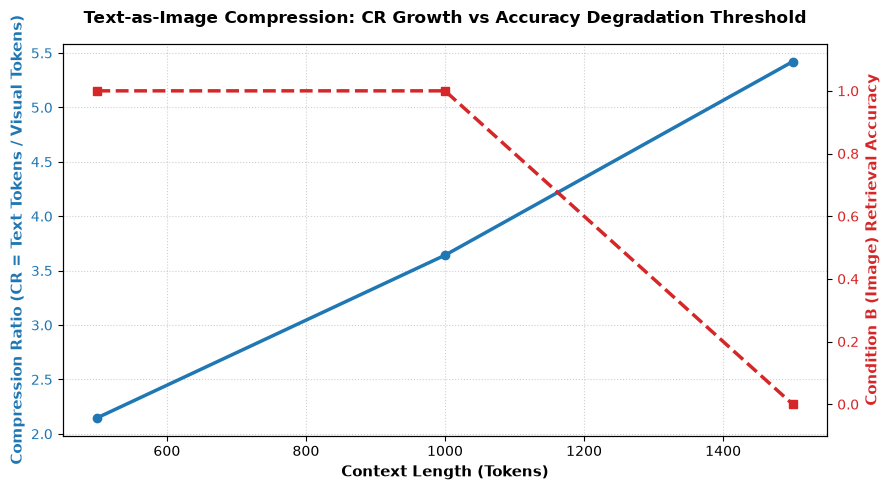

In [6]:
# =============================================================================
# Step 6: Visual Degradation Threshold & Efficiency Plots
# =============================================================================
fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot Compression Ratio on Primary Y-Axis
color = 'tab:blue'
ax1.set_xlabel('Context Length (Tokens)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Compression Ratio (CR = Text Tokens / Visual Tokens)', color=color, fontsize=11, fontweight='bold')
ax1.plot(df_results['context_length'], df_results['cr'], marker='o', color=color, linewidth=2.5, label='Compression Ratio (CR)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle=':', alpha=0.6)

# Secondary Y-Axis for Accuracy Retention
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Condition B (Image) Retrieval Accuracy', color=color, fontsize=11, fontweight='bold')
ax2.plot(df_results['context_length'], df_results['acc_image'], marker='s', linestyle='--', color=color, linewidth=2.5, label='Image Accuracy')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-0.1, 1.15)

plt.title('Text-as-Image Compression: CR Growth vs Accuracy Degradation Threshold', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()